In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:/Users/haree/Downloads/stage_2_train.csv"
df = pd.read_csv(path)
df[['Image_ID', 'Subtype']] = df['ID'].str.rsplit('_', n=1, expand=True)

#### EDA

Total Unique Images in Dataset: 752,803
Normal Scans: 644,870 (85.66%)
Hemorrhage Scans: 107,933 (14.34%)

         Subtype  Count  Percentage (%)
             any 107933       14.337483
        subdural  47166        6.265384
intraparenchymal  36118        4.797802
    subarachnoid  35675        4.738956
intraventricular  26205        3.480990
        epidural   3145        0.417772


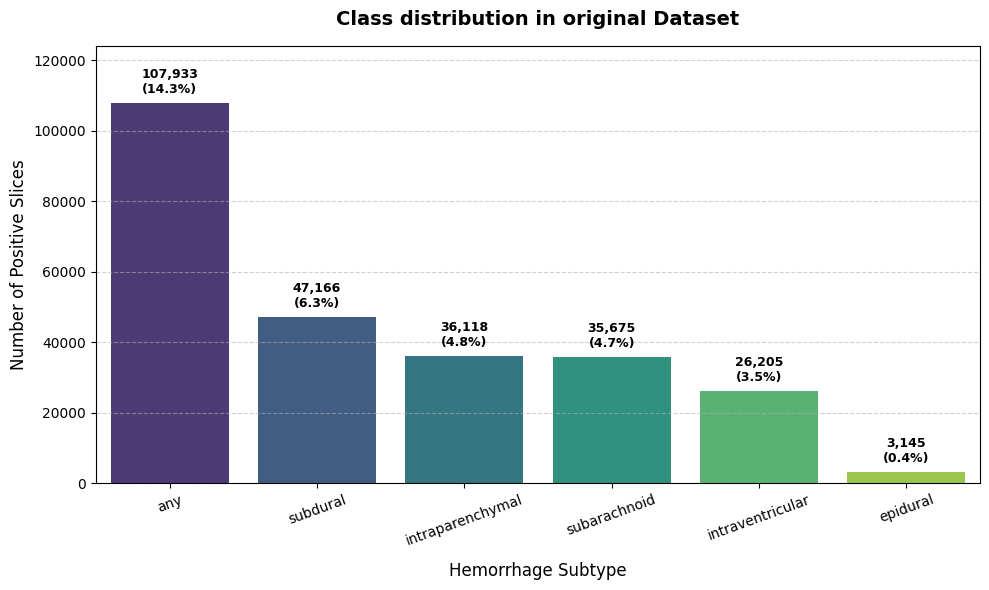

In [6]:
df.drop_duplicates(subset=['ID'], keep='first', inplace=True)

# Pivot the dataframe to get 1 row per Image_ID
df_pivoted = df.pivot(index='Image_ID', columns='Subtype', values='Label').reset_index()
df_pivoted.columns.name = None

# Hemorrhage vs Normal Split
df_pivoted['Normal'] = (df_pivoted['any'] == 0).astype(int)
normal_count = df_pivoted['Normal'].sum()
hemorrhage_count = df_pivoted['any'].sum()
total_images = len(df_pivoted)

print(f"Total Unique Images in Dataset: {total_images:,}")
print(f"Normal Scans: {normal_count:,} ({normal_count/total_images*100:.2f}%)")
print(f"Hemorrhage Scans: {hemorrhage_count:,} ({hemorrhage_count/total_images*100:.2f}%)\n")

# subtype Counts & Percentages Dataframe
subtypes = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']
counts_df = df_pivoted[subtypes].sum().reset_index()
counts_df.columns = ['Subtype', 'Count']

counts_df['Percentage (%)'] = (counts_df['Count'] / total_images) * 100
counts_df = counts_df.sort_values(by='Count', ascending=False).reset_index(drop=True)

print(counts_df.to_string(index=False))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=counts_df, 
    x='Subtype', 
    y='Count', 
    hue='Subtype', 
    palette='viridis', 
    legend=False
)

plt.title("Class distribution in original Dataset", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Hemorrhage Subtype", fontsize=12, labelpad=10)
plt.ylabel("Number of Positive Slices", fontsize=12)
plt.xticks(rotation=20, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for p, pct in zip(ax.patches, counts_df['Percentage (%)']):
    height = p.get_height()
    ax.annotate(
        f'{int(height):,}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', 
        va='bottom',
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=9, 
        fontweight='bold'
    )

plt.ylim(0, counts_df['Count'].max() * 1.15)

plt.tight_layout()
plt.show()

#### Sampling
##### 10% of original(~75k & ~37GB)

In [ ]:
from sklearn.model_selection import train_test_split

# Create a unique signature for every multi-label combination
subtypes = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']
df_pivoted['stratify_key'] = df_pivoted[subtypes + ['any']].astype(str).agg('_'.join, axis=1)

# Identify the rare keys (Appearing only once)
counts = df_pivoted['stratify_key'].value_counts()
rare_combos = counts[counts == 1].index

# Fast vectorized replacement 
df_pivoted.loc[df_pivoted['stratify_key'].isin(rare_combos), 'stratify_key'] = 'rare_combo'

# Take a 10% Sample stratified by the combination key
_, df_sample = train_test_split(
    df_pivoted, 
    test_size=0.10, 
    stratify=df_pivoted['stratify_key'], 
    random_state=42
)

df_sample.to_csv("rsna_train_sample.csv", index=False)

print(f"Sample size: {len(df_sample)} images.")

Sample size: 75281 images.


#### Class Distribution (sample)

In [10]:
subtypes_list = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']
sample_counts = df_sample[subtypes_list].sum().reset_index()
sample_counts.columns = ['Subtype', 'Label']

total_sample_images = len(df_sample)
sample_counts['Percentage (%)'] = (sample_counts['Label'] / total_sample_images) * 100

print(f"Total Unique Images in Sample: {total_sample_images}\n")
print(sample_counts.sort_values(by='Label', ascending=False).to_string(index=False))

Total Unique Images in Sample: 75281

         Subtype  Label  Percentage (%)
             any  10793       14.336951
        subdural   4716        6.264529
intraparenchymal   3612        4.798023
    subarachnoid   3568        4.739576
intraventricular   2622        3.482951
        epidural    314        0.417104


#### Comparing Distibutions

In [11]:
# Calculate percentages for Original vs Sample
orig_percents = (df_pivoted[subtypes + ['any']].sum() / len(df_pivoted)) * 100
sample_percents = (df_sample[subtypes + ['any']].sum() / len(df_sample)) * 100

# Merge into a comparison dataframe
comparison_df = pd.DataFrame({
    'Original %': orig_percents,
    'Subset %': sample_percents
})

print(comparison_df)

                  Original %   Subset %
epidural            0.417772   0.417104
intraparenchymal    4.797802   4.798023
intraventricular    3.480990   3.482951
subarachnoid        4.738956   4.739576
subdural            6.265384   6.264529
any                14.337483  14.336951


#### checking if downloaded dataset matches the sampling

In [13]:
import os
import pandas as pd

IMAGE_FOLDER = r"C:\Users\haree\Downloads\rsna_sample_dataset" 
CSV_PATH = r"C:\Users\haree\OneDrive\Documents\rsna_train_sample.csv" 
CLEANED_CSV_PATH = r"C:\Users\haree\OneDrive\Documents\rsna_train_sample_final.csv"

print("Scanning local image folder...")
disk_files = set(os.path.splitext(f)[0] for f in os.listdir(IMAGE_FOLDER))
print(f"Total files found on disk: {len(disk_files):,}")

df = pd.read_csv(CSV_PATH)

id_col = 'ID' if 'ID' in df.columns else df.columns[0]
df[id_col] = df[id_col].astype(str).str.replace('.dcm', '', regex=False)

csv_ids = set(df[id_col])
print(f"Total IDs in sample CSV: {len(csv_ids):,}")

missing_on_disk = csv_ids - disk_files
extra_on_disk = disk_files - csv_ids

print("\n--- Match ---")
if len(missing_on_disk) > 0:
    print(f"Missing from disk ({len(missing_on_disk)}): {missing_on_disk}")
else:
    print("No missing files!")

if len(extra_on_disk) > 0:
    print(f"Unexpected files on disk ({len(extra_on_disk)}): {extra_on_disk}")
else:
    print("No unexpected files on disk!")

df_final = df[df[id_col].isin(disk_files)].copy()
df_final.to_csv(CLEANED_CSV_PATH, index=False)
print(f"\nSaved updated CSV with {len(df_final):,} rows to: {CLEANED_CSV_PATH}")

Scanning local image folder...
Total files found on disk: 75,279
Total IDs in sample CSV: 75,281

--- Match ---
Missing from disk (2): {'ID_48759f6ec', 'ID_1767a2f23'}
No unexpected files on disk!

Saved updated CSV with 75,279 rows to: C:\Users\haree\OneDrive\Documents\rsna_train_sample_final.csv


#### class distribution of final sample

Total Unique Images in Final Dataset: 75,279

         Subtype  Label  Percentage (%)
             any  10792       14.336003
        subdural   4715        6.263367
intraparenchymal   3612        4.798151
    subarachnoid   3568        4.739702
intraventricular   2622        3.483043
        epidural    314        0.417115


C:\Users\haree\AppData\Local\Temp\ipykernel_15516\2350874299.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


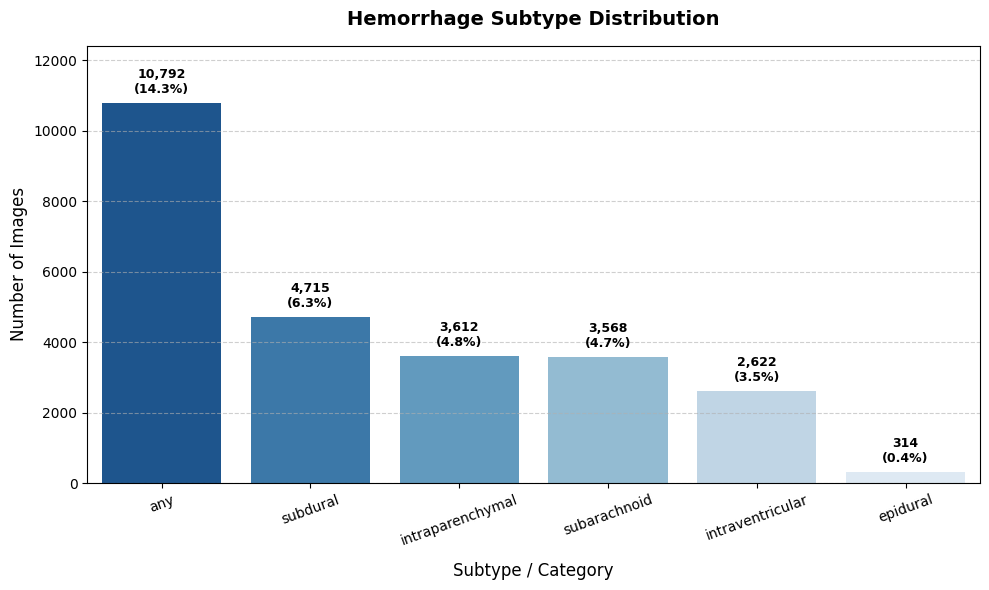

In [ ]:
df_final = pd.read_csv(r"C:\Users\haree\OneDrive\Documents\rsna_train_sample_final.csv")

subtypes_list = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']
sample_counts = df_final[subtypes_list].sum().reset_index()
sample_counts.columns = ['Subtype', 'Label']

total_sample_images = len(df_final)
sample_counts['Percentage (%)'] = (sample_counts['Label'] / total_sample_images) * 100

sample_counts = sample_counts.sort_values(by='Label', ascending=False).reset_index(drop=True)

print(f"Total Unique Images in Final Dataset: {total_sample_images:,}\n")
print(sample_counts.to_string(index=False))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=sample_counts, 
    x='Subtype', 
    y='Label', 
    palette='Blues_r'
)

plt.title('Hemorrhage Subtype Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Subtype / Category', fontsize=12, labelpad=10)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=20, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for p, pct in zip(ax.patches, sample_counts['Percentage (%)']):
    height = p.get_height()
    ax.annotate(
        f'{int(height):,}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', 
        va='bottom',
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=9, 
        fontweight='bold'
    )

plt.ylim(0, sample_counts['Label'].max() * 1.15)

plt.tight_layout()
plt.show()

#### Dicom handling

Metadata Across 500 images
                         mean        std          min         max
SliceThickness            NaN        NaN          NaN         NaN
PixelSpacing_X       0.478264   0.024565     0.382812    0.566406
PixelSpacing_Y       0.478264   0.024565     0.382812    0.566406
RescaleIntercept -1017.616000  79.177008 -1024.000000    0.000000
RescaleSlope         1.000000   0.000000     1.000000    1.000000
Rows               512.000000   0.000000   512.000000  512.000000
Columns            512.000000   0.000000   512.000000  512.000000


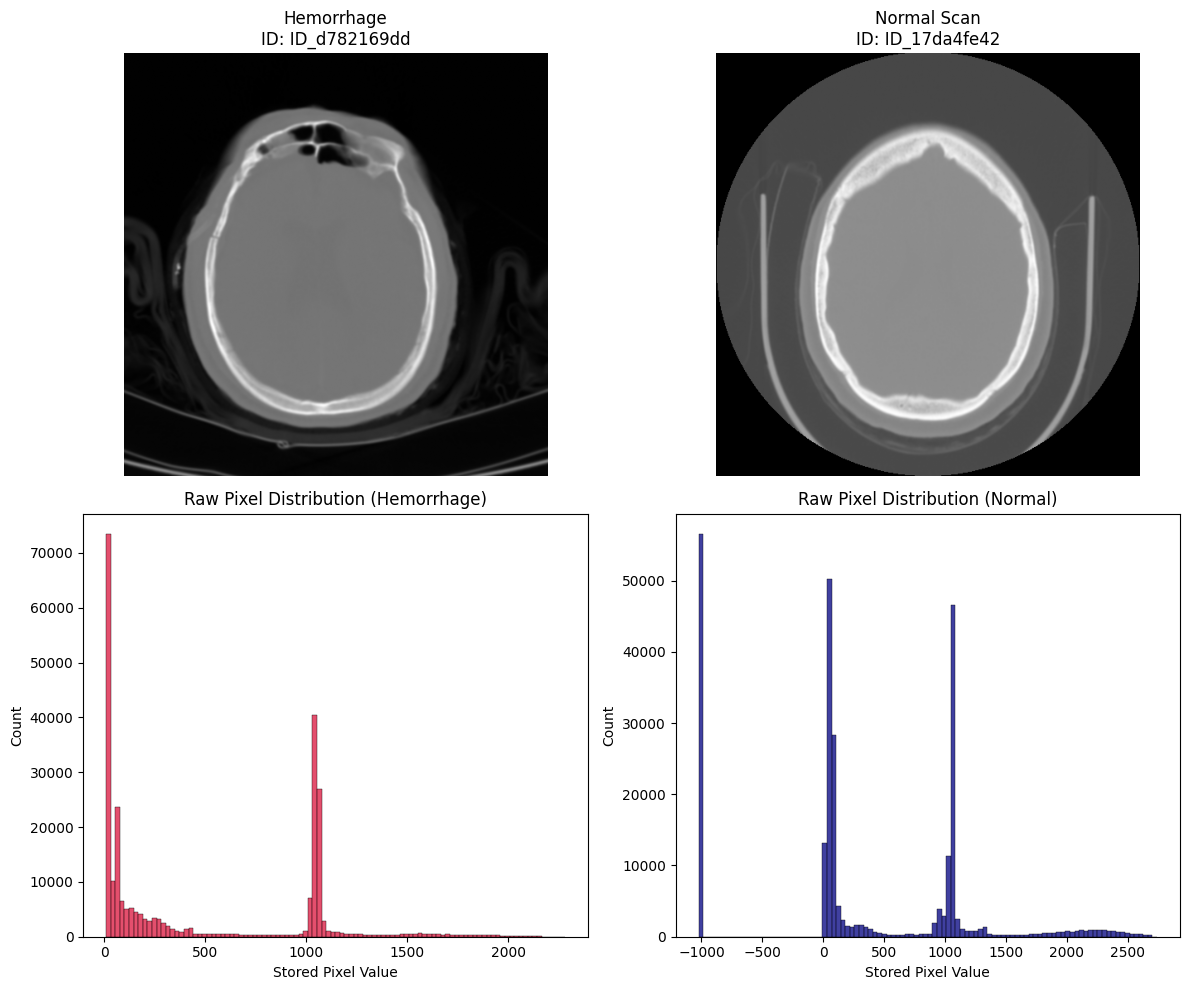

,Label,Image_ID,Rows x Cols,Pixel Spacing,Rescale Intercept,Rescale Slope,Window Center,Window Width
0,Hemorrhage,ID_d782169dd,512 x 512,0.4883 mm,-1024.0,1.0,"[00036, 00036]","[00080, 00080]"
1,Normal,ID_17da4fe42,512 x 512,0.4883 mm,-1024.0,1.0,40.0,150.0


In [9]:
import os
import glob
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IMAGE_FOLDER = r"C:\Users\haree\Downloads\rsna_sample_dataset"
df_final = pd.read_csv(r"C:\Users\haree\OneDrive\Documents\rsna_train_sample_final.csv")

print("Metadata Across 500 images")

sample_files = glob.glob(os.path.join(IMAGE_FOLDER, "*.dcm"))[:500]

metadata_list = []
for fpath in sample_files:
    dcm = pydicom.dcmread(fpath, stop_before_pixels=True)
    metadata_list.append({
        'Image_ID': os.path.basename(fpath).replace('.dcm', ''),
        'SliceThickness': getattr(dcm, 'SliceThickness', np.nan),
        'PixelSpacing_X': dcm.PixelSpacing[0] if 'PixelSpacing' in dcm else np.nan,
        'PixelSpacing_Y': dcm.PixelSpacing[1] if 'PixelSpacing' in dcm else np.nan,
        'RescaleIntercept': getattr(dcm, 'RescaleIntercept', np.nan),
        'RescaleSlope': getattr(dcm, 'RescaleSlope', np.nan),
        'Rows': getattr(dcm, 'Rows', np.nan),
        'Columns': getattr(dcm, 'Columns', np.nan),
    })

meta_df = pd.DataFrame(metadata_list)
print(meta_df.describe().T[['mean', 'std', 'min', 'max']])

def load_raw_pixels(dcm_path):
    """Loads DICOM and returns raw stored pixel values."""
    dcm = pydicom.dcmread(dcm_path)
    raw_pixels = dcm.pixel_array.astype(np.float32)
    return raw_pixels, dcm

# Pick 1 Normal scan and 1 Hemorrhage scan
pos_id = df_final[df_final['any'] == 1]['Image_ID'].iloc[0]
neg_id = df_final[df_final['any'] == 0]['Image_ID'].iloc[0]

pos_path = os.path.join(IMAGE_FOLDER, f"{pos_id}.dcm")
neg_path = os.path.join(IMAGE_FOLDER, f"{neg_id}.dcm")

img_pos, dcm_pos = load_raw_pixels(pos_path)
img_neg, dcm_neg = load_raw_pixels(neg_path)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_pos, cmap='gray')
axes[0, 0].set_title(f"Hemorrhage\nID: {pos_id}")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_neg, cmap='gray')
axes[0, 1].set_title(f"Normal Scan\nID: {neg_id}")
axes[0, 1].axis('off')

# Raw Pixel Value Histograms
sns.histplot(img_pos.flatten(), bins=100, ax=axes[1, 0], color='crimson', kde=False)
axes[1, 0].set_title("Raw Pixel Distribution (Hemorrhage)")
axes[1, 0].set_xlabel("Stored Pixel Value")

sns.histplot(img_neg.flatten(), bins=100, ax=axes[1, 1], color='navy', kde=False)
axes[1, 1].set_title("Raw Pixel Distribution (Normal)")
axes[1, 1].set_xlabel("Stored Pixel Value")

plt.tight_layout()
plt.show()

# Metadata for these scans
sample_ids = [pos_id, neg_id]
sample_dcms = [dcm_pos, dcm_neg]
labels = ["Hemorrhage", "Normal"]

detailed_meta = []
for label, img_id, dcm in zip(labels, sample_ids, sample_dcms):
    detailed_meta.append({
        "Label": label,
        "Image_ID": img_id,
        "Rows x Cols": f"{getattr(dcm, 'Rows', 'N/A')} x {getattr(dcm, 'Columns', 'N/A')}",
        "Pixel Spacing": f"{getattr(dcm, 'PixelSpacing', ['N/A'])[0]:.4f} mm" if 'PixelSpacing' in dcm else "N/A",
        "Rescale Intercept": getattr(dcm, 'RescaleIntercept', 'N/A'),
        "Rescale Slope": getattr(dcm, 'RescaleSlope', 'N/A'),
        "Window Center": getattr(dcm, 'WindowCenter', 'N/A'),
        "Window Width": getattr(dcm, 'WindowWidth', 'N/A'),
    })

sample_df = pd.DataFrame(detailed_meta)
display(sample_df)

In [10]:
import os
import pydicom

sample_id = df_final['Image_ID'].iloc[0]
sample_path = os.path.join(IMAGE_FOLDER, f"{sample_id}.dcm")

ds = pydicom.dcmread(sample_path, stop_before_pixels=True)

print(ds)

Dataset.file_meta -------------------------------
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 10000000296134
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.3.4
(0002,0013) Implementation Version Name         SH: 'RSNA Challenge 2019'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: ID_d782169dd
(0008,0060) Modality                            CS: 'CT'
(0010,0020) Patient ID                          LO: 'ID_683fd24c'
(0020,000D) Study Instance UID                  UI: ID_6ceaf0e818
(0020,000E) Series Instance UID                 UI: ID_5f100746b5
(0020,0010) Study ID                            SH: ''
(0020,0032) Image Position (Patient)            DS: [-125, 44, 155.299988]
(0020,0037) Image Orientation (Patient)         DS: [1, 0, 0, 0, 1, 0]
(0028,0002) Samples per Pixel  

C:\Users\haree\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pydicom\valuerep.py:440: UserWarning: The value length (20) exceeds the maximum length of 16 allowed for VR SH.
  warn_and_log(msg)
C:\Users\haree\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_d782169dd'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
C:\Users\haree\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_6ceaf0e818'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
